In [1]:
import torch
import sys, os
import math as mt

src_dir = os.path.join(os.path.abspath(''), '..')  # goes up from models/ to src/
sys.path.insert(0, os.path.abspath(src_dir))

In [2]:
from models.autoencoder import Autoencoder
from models.autoencoder import trainSAE, testSAE
from utils.data_loading import QMatrixData

K = 5
lr = 5e-4
train_epochs = 500
in_channels = 4 
num_channels = 10
kernel_dim = 2
maze_dim = 4
batch_size = 10
gamma_sparse = 1/20*mt.sqrt(maze_dim**2*in_channels/K)
device = None

In [27]:
import numpy as np
import random
seed = 39
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

In [28]:
BASE_DIR = os.path.abspath(os.path.join(os.path.abspath(''), '..', '..', '..'))

train_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestraining_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstraining_4x4.pkl")
)
test_dataset = QMatrixData(
    q_file_path=os.path.join(BASE_DIR, "data/teacher/q matrix dictionaries/q_matricestest_4x4.pkl"),
    label_file_path=os.path.join(BASE_DIR, "data/teacher/label dictionaries/q_matrices_labelstest_4x4.pkl")
)

autoencoder = Autoencoder(in_channels, maze_dim, num_channels, kernel_dim, K)
optimizer = torch.optim.Adam(autoencoder.parameters(), lr=lr)

# training language
total_losses, recon_losses, sparsity_losses, all_messages = trainSAE(autoencoder, train_dataset, gamma_sparse, optimizer, batch_size, train_epochs, device)

# getting messages from trained language
_, _, _, all_messages = testSAE(autoencoder, train_dataset, batch_size, gamma_sparse, device)

/Users/melodycui/Downloads/cos435_final_project/.venv/lib/python3.12/site-packages/torch/storage.py:414: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  return torch.load(io.B

total loss: 698.6508178710938
reconstruction loss: 694.2901611328125
sparsity loss: 4.360735893249512

total loss: 655.9727783203125
reconstruction loss: 654.5194702148438
sparsity loss: 1.453258991241455

total loss: 593.7706909179688
reconstruction loss: 592.7689208984375
sparsity loss: 1.0017614364624023

total loss: 494.4873962402344
reconstruction loss: 493.6560363769531
sparsity loss: 0.8313766717910767

total loss: 361.05316162109375
reconstruction loss: 360.0083312988281
sparsity loss: 1.0448215007781982

total loss: 256.0772399902344
reconstruction loss: 255.06564331054688
sparsity loss: 1.011609435081482

total loss: 225.7595977783203
reconstruction loss: 225.0553436279297
sparsity loss: 0.7042414546012878

total loss: 220.06590270996094
reconstruction loss: 219.4037322998047
sparsity loss: 0.662185788154602

total loss: 217.51954650878906
reconstruction loss: 216.8422393798828
sparsity loss: 0.6773000359535217

total loss: 215.733154296875
reconstruction loss: 214.9738311767

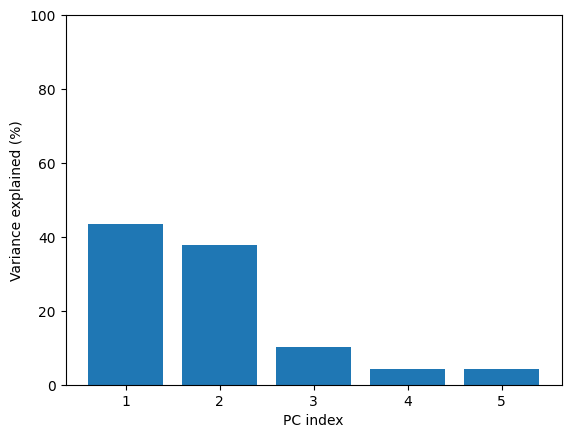

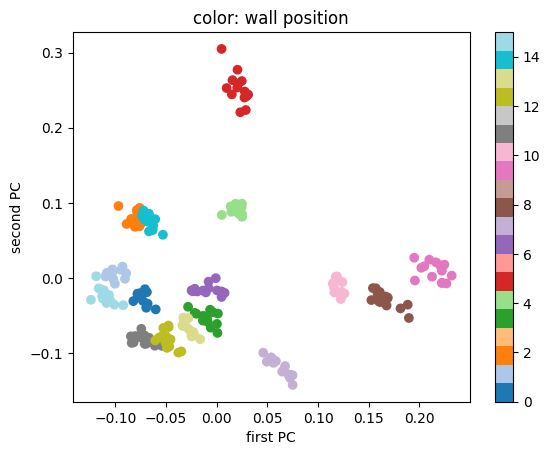

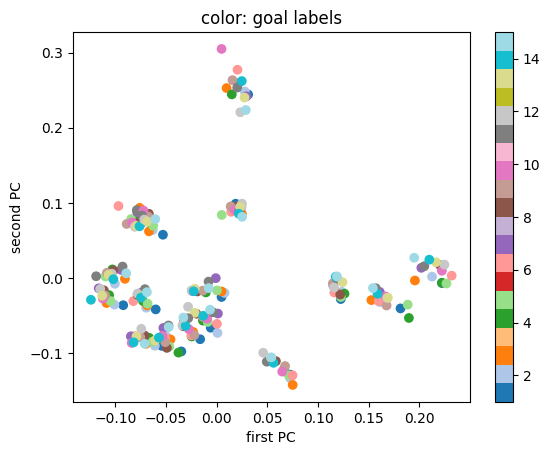

In [29]:
from sklearn.decomposition import PCA
from utils.plotting import plot_pca_variance, plot_pca_by_label

# Stack all messages into a single tensor
messages = torch.cat(all_messages, dim=0)  # shape: (num_tasks, K)
messages_np = messages.numpy()

wall_labels = [train_dataset.labels[i][0] for i in range(225)]
goal_labels = [train_dataset.labels[i][2] for i in range(225)]

pca = PCA(n_components=5)
pca_result = pca.fit_transform(messages_np)

# get plots
plot_pca_variance(pca)
plot_pca_by_label(pca_result, wall_labels, "color: wall position")
plot_pca_by_label(pca_result, goal_labels, "color: goal labels")